# Part 1

# TODO: Possibly add prediction error, check all parts are complete, figure out why line is below where it should be, verify in Colab


I used ChatGPT to understand the formulas given in the Linear Regression Optional Reading. I also used it to generate examples of linear regression from a theoretical standpoint in order to better understand the content. All code is my own

I first spent time understanding linear regression better. I read through the optional reading multiple times, and I asked ChatGPT to explain the variables in the mathematical equation. It took some time before I understood the proof behind the given algorithm. After that, I wrote it in Python on my own. On my first attempt, I failed to sum the errors across all data points. After fixing that, the model still did not work. I checked each line individually and found that I accidentally subracted instead of added in one location. 

h(x) = 1.7095936444387765e-07x + -139.9240509797051

I display several plots underneath my code, including the loss graph, slope and bias graphs, and the training and test data with the line of best fit marked. 

In [59]:
!pip install matplotlib
!pip install numpy

In [60]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define learn function

def learn(num_iter, x_train, y_train):
    alpha = 0.0001
    weight_history = []
    error_history = []
    num_weights = 4 # Use 4 params for cubic (3 coefficients plus a bias term)
    weights = np.array([np.random.random() / 10] * num_weights) # seed the weights

    j = 0

    while j < num_iter:
        x_j_input = x_train[j % len(x_train)] # Single input
        input_j = np.array([x_j_input ** i for i in range(num_weights)]) # Use 1 as the x input val for bias

        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            print(f"X_train[n] is {x_train[n]}, weights are {weights}")
            weighted_input_n = np.array([weights[i] * x_train[n] ** i for i in range(num_weights)]) 
            input_n = np.array([x_train[n] ** i for i in range(num_weights)]) 
            pred_val = np.sum(weighted_input_n) 
            # print(f"Sum is {pred_val} from values {weights * input_j}")
            loss = (y_train[n] - pred_val) * input_n # A vector of loss for each parameter (weight and bias)
            loss_sum = loss_sum + loss

        error_history.append(np.sum(loss_sum))
        # Update theta
        weights = weights + alpha * loss_sum
        weight_history.append(weights)

        j = j + 1
    
    return weights, weight_history, error_history, loss_sum


In [62]:
# Load Data

x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")
x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")
print(y_train)

# ind_temp = []
# x_temp = []
# y_temp = []
# for i in range(len(x_train)):
#     if x_train[i] < 1 and x_train[i]  > -1:
#         x_temp.append(x_train[i])
#         y_temp.append(y_train[i])

# print(len(x_temp))
# print(len(y_temp))
# x_train = x_temp
# y_train = y_temp

[ 1.35839541e+03  1.31962297e+03  5.14761884e+00 -8.99414045e-02
  2.39302944e+01 -3.69162774e+01  1.26561101e+01  6.90615217e+02
  7.69086805e+01 -5.05647573e+01  3.12530807e+02 -2.11268901e+02
 -3.64905229e+01  1.07683245e+01  4.32444663e+00  7.82085016e+02
  5.69318034e+00 -2.69439777e+01  3.74779889e+00  1.30986754e+01
  6.53275297e+00 -7.77554727e+02  1.17107756e+00 -1.15824751e+02
 -4.04967400e+02  1.30112433e+01  1.11871790e+03  1.54987490e+03
 -9.28373180e+02  1.30786417e+01  1.94643290e+00 -4.58255707e+00
 -8.10016065e+01 -6.44785171e+02  2.68162257e+01  1.31454911e+01
 -3.29456646e+00  1.09755024e+00  1.89378581e+00 -2.56312704e+03
 -7.56036326e+02  5.60504231e+00 -1.68376091e+00 -2.20037982e+01
  1.67088423e+01  1.14665129e+01  7.98117972e+02 -6.73628999e+00
  1.31246414e+01 -1.33316119e+03  1.08565941e+01  5.32173900e+02
 -8.49061149e+01  8.69431033e+00  1.14320881e+01 -1.09325792e+01
  5.18804601e+00  9.45394992e+00  2.30011668e+00  5.32854364e+02
 -6.70448751e+01  1.23903

In [63]:
weights, weight_history, error_history, loss_sum = learn(200, x_train, y_train)
print(f"Learned params: {weights}")

X_train[n] is 2.9186839268946496, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is 2.9079148171729416, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is -0.08495122114814624, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is -0.504775222257682, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is 1.793523617176727, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is -1.235345582829576, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is 1.0824164330949078, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is 2.680254449611388, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is 2.0661985787160377, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is -1.3399275130498047, weights are [0.00096114 0.00096114 0.00096114 0.00096114]
X_train[n] is 2.4332423609341776, weights are [0.00096114 0.00096114 0.00096114

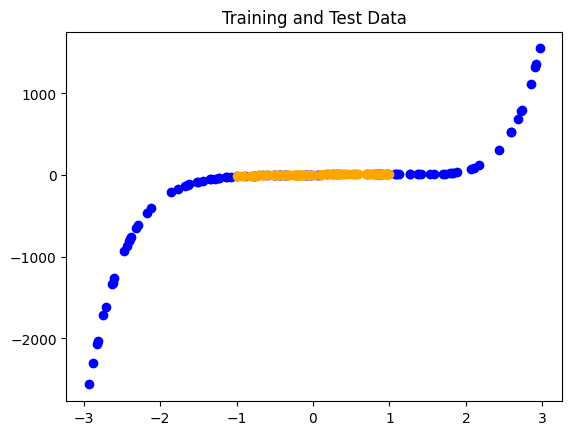

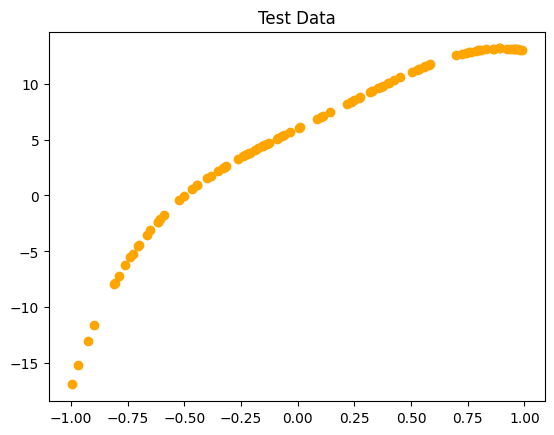

[  23.98301563 -107.85692729  -49.69501193   75.01181044]
23.983015633466362
[-2.92920705 -2.80884801 -2.68848898 -2.56812995 -2.44777091 -2.32741188
 -2.20705284 -2.08669381 -1.96633478 -1.84597574 -1.72561671 -1.60525767
 -1.48489864 -1.36453961 -1.24418057 -1.12382154 -1.0034625  -0.88310347
 -0.76274444 -0.6423854  -0.52202637 -0.40166733 -0.2813083  -0.16094927
 -0.04059023  0.0797688   0.20012784  0.32048687  0.4408459   0.56120494
  0.68156397  0.80192301  0.92228204  1.04264107  1.16300011  1.28335914
  1.40371818  1.52407721  1.64443624  1.76479528  1.88515431  2.00551335
  2.12587238  2.24623141  2.36659045  2.48694948  2.60730852  2.72766755
  2.84802658  2.96838562]
[np.float64(-1971.7748900015981), np.float64(-1727.457381220606), np.float64(-1502.8929622683395), np.float64(-1297.29690906725), np.float64(-1109.8844975397878), np.float64(-939.871003608403), np.float64(-786.4717031955475), np.float64(-648.9018722236715), np.float64(-526.3767866152252), np.float64(-418.1117222

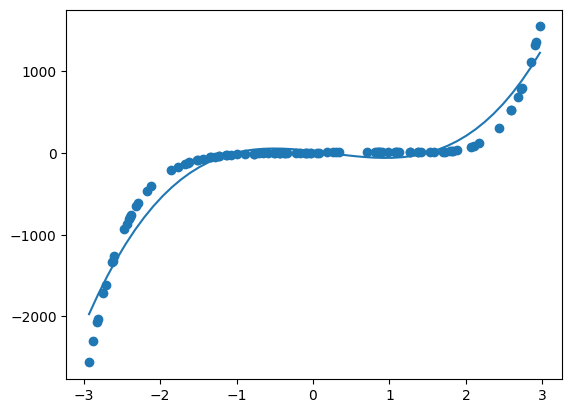

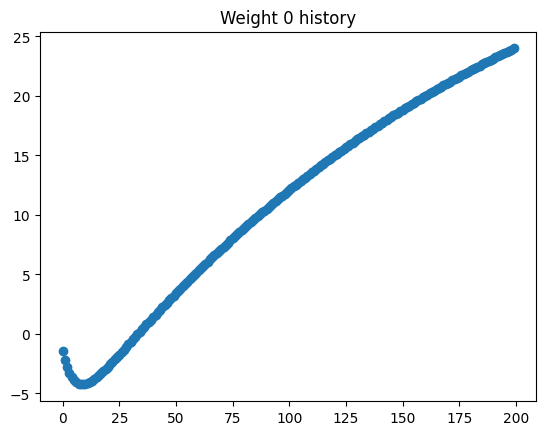

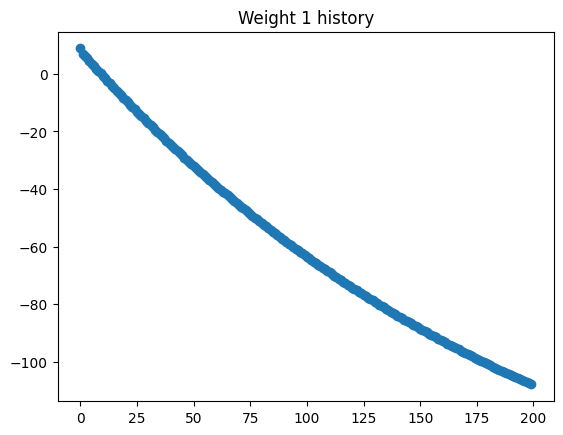

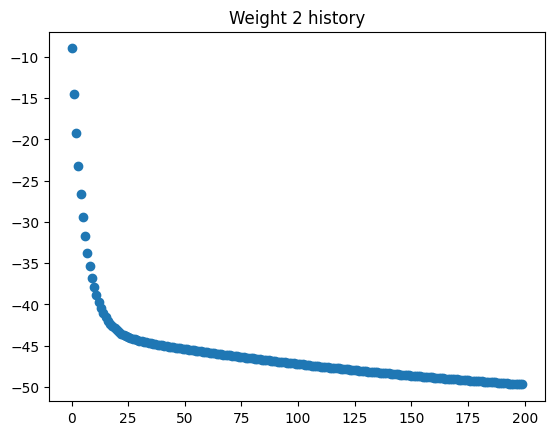

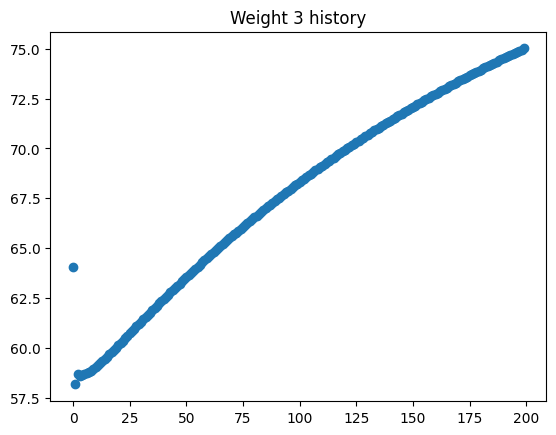

In [64]:
# Show results

plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_test, y_test, color="orange")
plt.title("Training and Test Data")
plt.show()


plt.scatter(x_test, y_test, color="orange")
plt.title("Test Data")
plt.show()

# plt.scatter(x_train, y_train)
# plt.plot([-2, 0,2], [bias + -2 * learned_slope, bias, bias + 2 * learned_slope], color="black")
# plt.title("Model with Training Data")
# plt.show()
plt.scatter(x_train, y_train)
x_space = np.linspace(np.min(x_train), np.max(x_train))
num_weights = len(weights)
print(weights)
print(np.sum(weights * [0 ** i for i in range(num_weights)]))
print(x_space)
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
print(model_predictions)
plt.plot(x_space, model_predictions)
plt.show()

# plt.scatter(x_test, y_test)
# plt.plot([-1, 0,1], [bias + learned_slope * -1, bias, bias + learned_slope], color="black")
# plt.title("Model with Test Data")
# plt.show()

# Plot history of each parameter
weight_history = np.array(weight_history)
for i in range(len(weights)):
    data = weight_history[:,i]
    plt.scatter([i for i in range(0, len(data))], data)
    plt.title(f"Weight {i} history")
    plt.show()

# plt.scatter([i for i in range(0, len(bias_history))], bias_history)
# plt.title("Bias history")
# plt.show()

# plt.title("Loss History")
# print(error_history)
# plt.scatter([i for i in range(0, len(error_history))], error_history)
# plt.show()

# Part 2

## Status: working on loading CSVs correctly, then planning on running "learn" function on one to get it to work, then find a way to return a predicted error or other metric and run on all in loop, and pick the best fit one

In [65]:
import matplotlib.pyplot as plt
import numpy as np

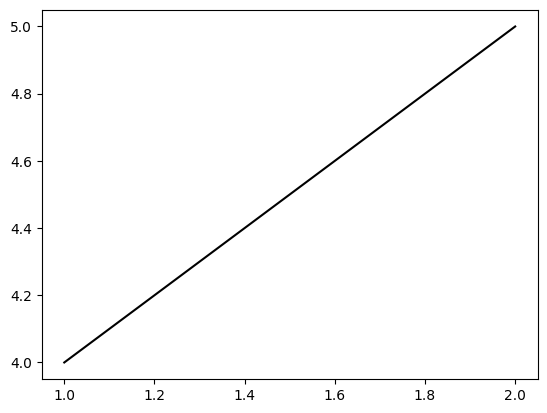

In [66]:

# plt.scatter([1,2], [10,20])
first_x = 1
last_x = 2
bias = 3
learned_slope = 1
plt.plot([first_x, last_x], [bias + first_x * learned_slope, bias + last_x * learned_slope], color="black")
plt.show()

In [67]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

for n in data_formats["names"]:
    if n == 'price':
        continue
    print("\n\n", n)
    housing_train_input = housing_train[n]

    learned_slope, bias, slope_history, bias_history, error_history, final_loss = learn(200, housing_train_input, housing_train_output)
    print(f"Learned slope: {learned_slope}")
    print(f"Learned bias: {bias}")
    print(f"Equation: h(x) = {learned_slope}x + {bias}")
    print(f"Loss is {final_loss}")

    plt.scatter(housing_train_input, housing_train_output)
    first_x = np.min(housing_train_input)
    last_x = np.max(housing_train_input)
    plt.plot([first_x, last_x], [bias - first_x * learned_slope, bias + last_x * learned_slope], color="black")
    plt.title(f"Price vs {n}")
    plt.show()



 id
X_train[n] is 1, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 2, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 3, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 4, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 5, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 6, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 7, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 8, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 9, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 10, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 11, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 12, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 13, weights are [0.07897679 0.07897679 0.07897679 0.07897679]
X_train[n] is 1

C:\Users\ghawk\AppData\Local\Temp\ipykernel_12084\1479359.py:25: RuntimeWarning: overflow encountered in add
  loss_sum = loss_sum + loss
C:\Users\ghawk\AppData\Local\Temp\ipykernel_12084\1479359.py:24: RuntimeWarning: overflow encountered in multiply
  loss = (y_train[n] - pred_val) * input_n # A vector of loss for each parameter (weight and bias)
C:\Users\ghawk\AppData\Local\Temp\ipykernel_12084\1479359.py:29: RuntimeWarning: invalid value encountered in add
  weights = weights + alpha * loss_sum


ValueError: not enough values to unpack (expected 6, got 4)